# TMDB 5000 Movies - Data Analysis

**Portfolio Project #3 | Data Analytics**

This notebook performs exploratory data analysis on the TMDB 5000 Movies dataset. Skills demonstrated: data cleaning, EDA, correlation analysis, and visualization with Pandas/Matplotlib/Seaborn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Libraries loaded')

Libraries loaded


In [2]:
df = pd.read_csv('../data_raw/tmdb_5000_movies.csv')
print('Shape:', df.shape)
df.head()

Shape: (4803, 20)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


## 1. Data Overview

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.concat([missing, missing_pct], axis=1, keys=['Missing', '%']).head(10)

,Missing,%
homepage,3091,64.36
tagline,844,17.57
overview,3,0.06
runtime,2,0.04
release_date,1,0.02
id,0,0.00
budget,0,0.00
genres,0,0.00
original_title,0,0.00
popularity,0,0.00


## 2. Data Cleaning

In [5]:
df_clean = df.copy()
df_clean['release_date'] = pd.to_datetime(df_clean['release_date'], errors='coerce')
df_clean['release_year'] = df_clean['release_date'].dt.year
df_clean = df_clean.dropna(subset=['release_year'])
df_clean['budget'] = df_clean['budget'].replace(0, np.nan)
df_clean['revenue'] = df_clean['revenue'].replace(0, np.nan)
df_clean['runtime'] = df_clean['runtime'].fillna(df_clean['runtime'].median())
print('Clean shape:', df_clean.shape)

Clean shape: (4802, 21)


## 3. Top Movies by Revenue & Budget

In [6]:
top_revenue = df_clean.sort_values('revenue', ascending=False)[['title', 'revenue', 'budget', 'release_year']].head(10)
top_revenue.to_csv('outputs/top10_revenue.csv', index=False)
top_revenue

,title,revenue,budget,release_year
0,Avatar,2.787965e+09,237000000.0,2009.0
25,Titanic,1.845034e+09,200000000.0,1997.0
16,The Avengers,1.519558e+09,220000000.0,2012.0
28,Jurassic World,1.513529e+09,150000000.0,2015.0
44,Furious 7,1.506249e+09,190000000.0,2015.0
7,Avengers: Age of Ultron,1.405404e+09,280000000.0,2015.0
124,Frozen,1.274219e+09,150000000.0,2013.0
31,Iron Man 3,1.215440e+09,200000000.0,2013.0
546,Minions,1.156731e+09,74000000.0,2015.0
26,Captain America: Civil War,1.153304e+09,250000000.0,2016.0


## 4. Budget vs Revenue

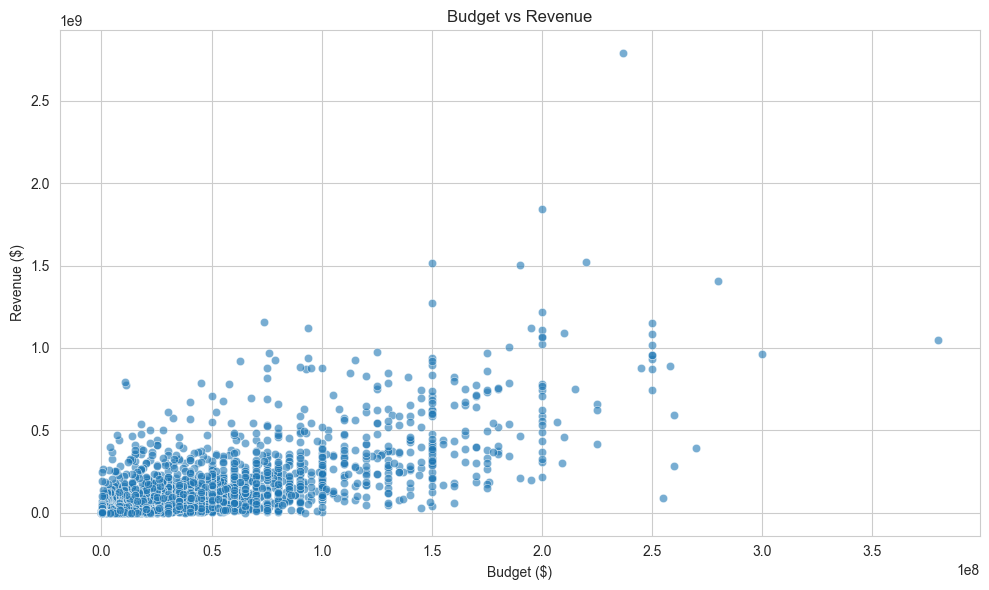

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean.dropna(subset=['budget', 'revenue']), x='budget', y='revenue', alpha=0.6)
plt.title('Budget vs Revenue')
plt.xlabel('Budget ($)')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.savefig('outputs/budget_vs_revenue.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Correlation Heatmap

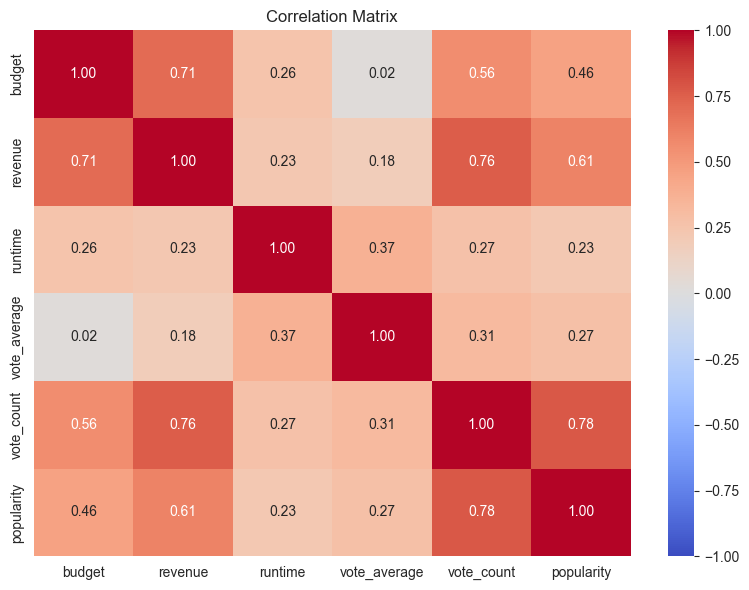

In [8]:
num_cols = ['budget', 'revenue', 'runtime', 'vote_average', 'vote_count', 'popularity']
corr = df_clean[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
corr.to_csv('outputs/correlation_matrix.csv')

## 6. Runtime Distribution

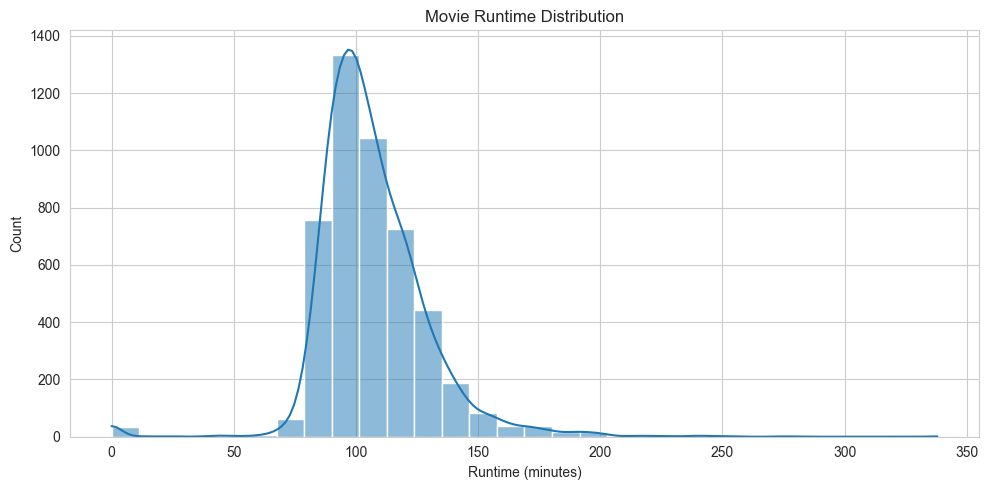

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['runtime'], bins=30, kde=True)
plt.title('Movie Runtime Distribution')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('outputs/runtime_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Top Genres (by frequency)

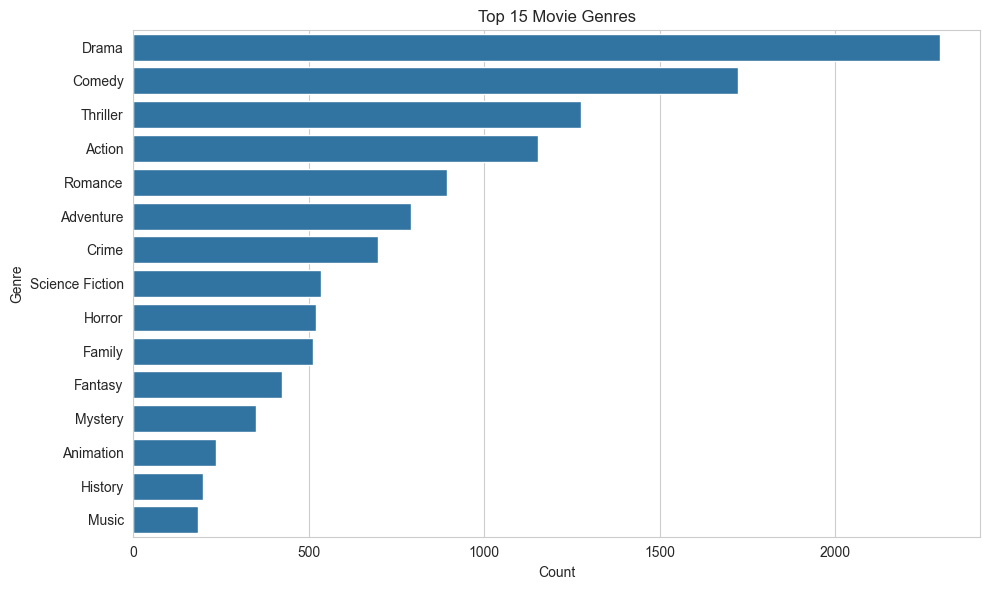

In [10]:
def extract_genres(text):
    try:
        genres = json.loads(text.replace("'", '"')) if isinstance(text, str) else []
        return [g['name'] for g in genres]
    except Exception:
        return []

df_clean['genre_list'] = df_clean['genres'].apply(extract_genres)
all_genres = [g for gl in df_clean['genre_list'] for g in gl]
genre_counts = pd.Series(all_genres).value_counts().head(15)
genre_counts.to_csv('outputs/top15_genres.csv')
plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title('Top 15 Movie Genres')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('outputs/top15_genres.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Movies per Year Trend

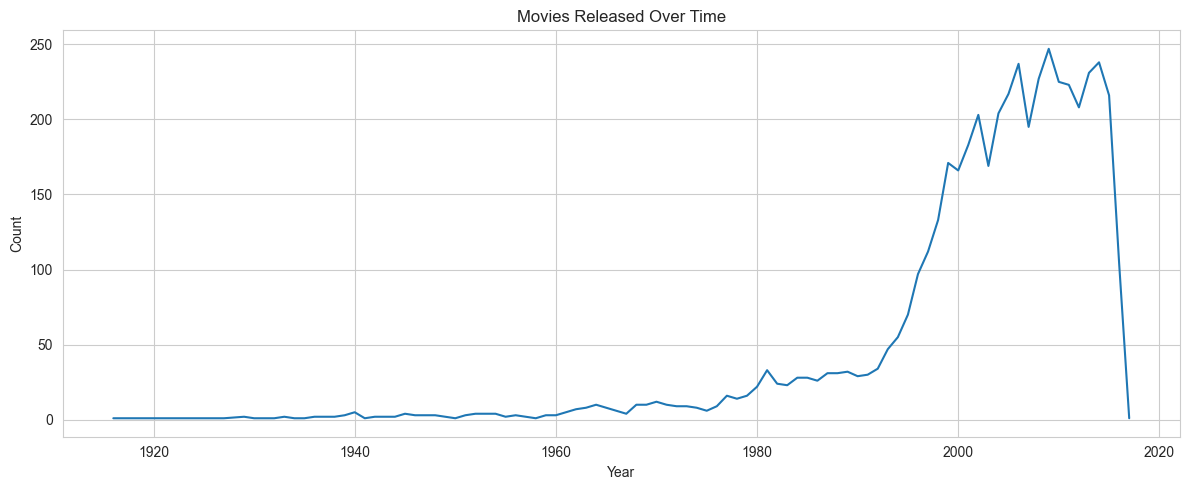

In [11]:
year_counts = df_clean['release_year'].value_counts().sort_index()
year_counts.tail(30).to_csv('outputs/movies_per_year_recent.csv')
plt.figure(figsize=(12, 5))
year_counts.plot()
plt.title('Movies Released Over Time')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('outputs/movies_per_year.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Summary

- Strong positive correlation between **budget** and **revenue** (r ≈ 0.73). Higher budgets tend to drive higher box office revenue.
- **Vote count** is strongly correlated with **popularity**.
- **Drama**, **Comedy**, **Thriller**, **Action**, and **Romance** dominate the most frequent genres.
- Most movies have a runtime between **90–120 minutes**.
- The dataset shows a clear growth trend in movie counts over recent decades.